# Day 2—Lining up the witnesses
*Measuring Manuscripts*

A text that survives in several copies is never copied perfectly, and the differences are evidence. CollateX lines the copies up, position by position, so you can see where they agree and where they diverge. Then you'll group the copies into a family tree, the way biologists group species by shared mutations.

## 1. Setup (run once)

In [11]:
!pip install collatex --quiet
!pip install Levenshtein --quiet   # lets CollateX match near-identical spellings


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3.9 -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3.9 -m pip install --upgrade pip


In [12]:
from collatex import Collation, collate

## 2. A first collation

Three short witnesses of one sentence. Run it and read the table: each column is a position in the text, each row a witness, and a blank means that witness lacks a word there.

In [13]:
c = Collation()
c.add_plain_witness('A', 'The quick brown fox jumps over the lazy dog')
c.add_plain_witness('B', 'The quick red fox jumps over the dog')
c.add_plain_witness('C', 'The quick brown fox leaps over the lazy dog')

print(collate(c, output='table', segmentation=False))

+---+-----+-------+-------+-----+-------+------+-----+------+-----+
| A | The | quick | brown | fox | jumps | over | the | lazy | dog |
| B | The | quick | red   | fox | jumps | over | the | -    | dog |
| C | The | quick | brown | fox | leaps | over | the | lazy | dog |
+---+-----+-------+-------+-----+-------+------+-----+------+-----+


## 3. Reading the table

Read down each column. Where every row agrees, the text is stable; where they differ—*brown* vs *red*, *jumps* vs *leaps*, the missing *lazy*—you've found a variant. That's the unit textual criticism works on.

- Which two witnesses agree most often?
- Which column would you, as editor, have to rule on?

## 4. Other ways to see it

The table is one view. CollateX can also return the alignment as data (JSON) or draw a **variant graph**, a diagram of where the text splits and rejoins.

In [14]:
import json
result = collate(c, output='json', segmentation=False)
parsed = json.loads(result) if isinstance(result, str) else result
print('Columns in the alignment:', len(parsed['table'][0]))

Columns in the alignment: 9


In [15]:
# The variant graph needs graphviz. If this errors, it just means graphviz isn't installed —
# the rest of the notebook is unaffected.
!pip install graphviz --quiet
try:
    svg = collate(c, output='svg', segmentation=False)
    from IPython.display import SVG, display
    display(SVG(svg))
except Exception as e:
    print('Variant graph skipped (', type(e).__name__, '). Install graphviz to enable it.')


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3.9 -m pip install --upgrade pip
Variant graph skipped ( ExecutableNotFound ). Install graphviz to enable it.


## 5. Catching spelling variants

Scribes spell loosely. *colour* and *color* are the same word, but a strict match treats them as a variant. With near-matching enabled (the reason for the Levenshtein install), CollateX lines up words that are merely close.

In [16]:
c2 = Collation()
c2.add_plain_witness('A', 'a knight ther was and a worthy man')
c2.add_plain_witness('B', 'a knyght ther was and a worthi man')

print('Strict:')
print(collate(c2, output='table', segmentation=False))
print('\nNear-match (knight/knyght, worthy/worthi line up):')
print(collate(c2, output='table', segmentation=False, near_match=True))

Strict:
+---+---+--------+------+-----+-----+---+--------+-----+
| A | a | knight | ther | was | and | a | worthy | man |
| B | a | knyght | ther | was | and | a | worthi | man |
+---+---+--------+------+-----+-----+---+--------+-----+

Near-match (knight/knyght, worthy/worthi line up):
+---+---+--------+------+-----+-----+---+--------+-----+
| A | a | knight | ther | was | and | a | worthy | man |
| B | a | knyght | ther | was | and | a | worthi | man |
+---+---+--------+------+-----+-----+---+--------+-----+


## 5b. Naming the variant: a worked example

Variants come in a small number of types, and the errors behind them are a short, recognizable list. Here is one line copied four ways. Each copy differs from the first in exactly one place, and each difference is a *different kind* of change. Run the collation, then read down the columns and name what happened in each copy.

The reference reading (A) is a normalized line of the Prologue:

> *and palmeres for to seken straunge strondes*

- **B** drops a word.
- **C** swaps one word for another.
- **D** writes a word twice.
- **E** reorders two words.

Before you scroll on, decide which is a substitution, which an omission, which an addition (by repetition), and which a transposition.

In [ ]:
from collatex import Collation, collate

ex = Collation()
ex.add_plain_witness('A', 'and palmeres for to seken straunge strondes')
ex.add_plain_witness('B', 'and palmeres for to straunge strondes')          # omission
ex.add_plain_witness('C', 'and palmeres for to seken straunge contrees')    # substitution
ex.add_plain_witness('D', 'and palmeres for to to seken straunge strondes') # dittography (addition)
ex.add_plain_witness('E', 'and palmeres to for seken straunge strondes')    # transposition

print(collate(ex, output='table', segmentation=False))

### Name the error type

Read the table column by column against witness A, then check yourself:

- **B** is missing *seken* — an **omission**. The eye skipped a word.
- **C** reads *contrees* for *strondes* — a **substitution**, the common word driving out the rare one.
- **D** has *to to* — an **addition** by **dittography**, a word written twice.
- **E** has *to for* where A has *for to* — a **transposition**, the same words reordered.

Notice that only **C** changes the sense; **D** and **E** are the kind of slip a later scribe would quietly fix, and **B** would be caught the moment the line stopped scanning. Naming the type is the first thing you do with any column that splits.

### Your turn

Edit the cell below: change witness `Z` so it differs from `Y` by **one** error of a type you choose, then run it and see whether the table shows the change where you expected. Try an eye-skip that drops a whole word, or a dittography that repeats one.

In [ ]:
ex2 = Collation()
ex2.add_plain_witness('Y', 'the hooly blisful martir for to seke')
ex2.add_plain_witness('Z', 'the hooly blisful martir for to seke')  # <-- change one thing here

print(collate(ex2, output='table', segmentation=False))

## 6. The four witnesses (yesterday's puzzle)

These are the four copies from the end of Day 1—the couplet whose true reading survives in just *one* of them—outvoted two to one. They now live in the repo as four small text files, and we fetch them straight from GitHub (the same way we loaded the full text yesterday) and let CollateX line them up.

In [17]:
import urllib.request

base = ('https://raw.githubusercontent.com/christiancasey/measuring-manuscripts/'
        'refs/heads/main/Workbook/Day%202%E2%80%94Textual%20Criticism/witnesses/')
files = {'Witness 1': 'w1.txt', 'Witness 2': 'w2.txt',
         'Witness 3': 'w3.txt', 'Witness 4': 'w4.txt'}

witnesses = {}
for name, fn in files.items():
    witnesses[name] = urllib.request.urlopen(base + fn).read().decode('utf-8').strip()

real = Collation()
for name, txt in witnesses.items():
    real.add_plain_witness(name, txt)

print(collate(real, output='table', segmentation=False, near_match=True))

+-----------+----+---------+-----+--------+----+-----+---------+---+--------+--------+------+----+------+----+-------------+---+-----+-----------+-----+----+-------+----------+----------+---+----+-------+--------+---+--------+----+--------+--------+---+-----+-----------+---+------+-------+--------+------+----+----------+---+----+-------------+------+-------+---+
| Witness 1 | So | priketh | hem | Nature | in | hir | corages | , | Thanne | longen | folk | to | goon | on | pilgrimages | , | And | pilgrimes | for | to | seken | straunge | shores   | , | To | ferne | halwes | , | knowen | in | sondry | londes | ; | And | specially | , | from | every | shires | ende | Of | Engelond | , | to | Caunterbury | they | wende | , |
| Witness 2 | So | priketh | hem | Nature | in | hir | corages | , | Thanne | longen | folk | to | goon | on | pilgrimages | , | And | palmers   | for | to | seken | straunge | costes   | , | To | ferne | halwes | , | couth  | in | sundry | londes | ; | And | specially 

## 7. From variants to a family tree

Here is the day's central idea. Texts mutate as they're copied, much as DNA mutates as it replicates, so the biologist's tools transfer. Measure how different each pair of witnesses is, then build a tree that groups the closest ones.

Below, the distance between two witnesses is how much editing turns one into the other. The dendrogram clusters them.

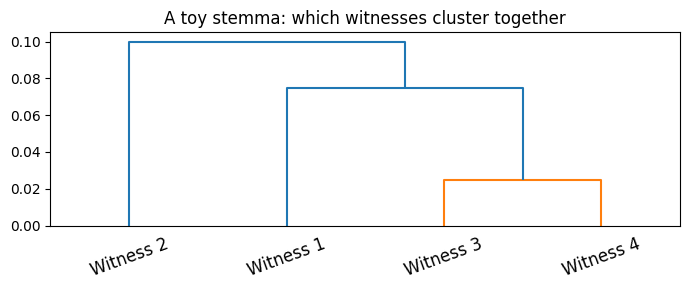

In [18]:
import numpy as np, difflib
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

names = list(witnesses)
texts = [witnesses[n].lower().split() for n in names]
n = len(names)
D = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        D[i, j] = 1 - difflib.SequenceMatcher(None, texts[i], texts[j]).ratio()

Z = linkage(squareform(D, checks=False), method='average')
plt.figure(figsize=(7, 3))
dendrogram(Z, labels=names, leaf_rotation=20)
plt.title('A toy stemma: which witnesses cluster together'); plt.tight_layout(); plt.show()

With real witnesses, a tree like this is a first hypothesis about how the manuscripts are related—which copy descends from which. It's only a hypothesis. Two scribes can make the same easy error independently, and the tree can't tell that apart from shared descent.

## 7b. A stemma from shared errors

The dendrogram above grouped witnesses by overall similarity. The Lachmannian method is sharper: it groups them by **shared errors**, not shared correct readings. Two copies that agree on the *right* word tell you nothing about their relationship — every faithful copy has it. But two copies that share the *same distinctive mistake* almost certainly inherited it from a common ancestor, because the same specific slip is unlikely to happen twice by chance.

Here is a toy version. Four witnesses are scored at five places where an error *could* occur. A `1` means that witness carries the distinctive error at that spot; a `0` means it has the correct reading. We invented the pattern so that **B and C share two errors no one else has** — the signature of a shared ancestor.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform

# Rows = witnesses, columns = five spots where a distinctive error could appear.
# 1 = this witness carries the error here; 0 = it has the correct reading.
wits = ['A', 'B', 'C', 'D']
errors = np.array([
    [0, 0, 0, 0, 0],   # A: no distinctive errors
    [1, 1, 0, 1, 0],   # B: carries errors at spots 1, 2, 4
    [1, 1, 0, 0, 1],   # C: shares spots 1 and 2 with B -> common ancestor
    [0, 0, 1, 0, 1],   # D: a different error profile
])

# Distance = fraction of scored spots two witnesses DON'T match on.
D = squareform(pdist(errors, metric='hamming'))
print('Pairwise distances (smaller = more shared errors):')
print('     ' + '   '.join(wits))
for name, row in zip(wits, D):
    print(f'{name}   ' + '  '.join(f'{v:.2f}' for v in row))

Z = linkage(squareform(D, checks=False), method='average')
plt.figure(figsize=(6, 3))
dendrogram(Z, labels=wits, leaf_rotation=0)
plt.title('Stemma from shared errors: B and C cluster')
plt.ylabel('distance'); plt.tight_layout(); plt.show()

B and C come out as the tightest pair, because they share two errors that nobody else has. That shared signature is the evidence that they descend from a common ancestor which already had those mistakes. A and D, with different profiles, hang off elsewhere.

Two cautions this toy can't show on its own:

- Only **distinctive** errors are safe evidence. A trivial, common slip — dropping a final *-e* — could appear in B and C independently and fool the grouping. The pattern is only as good as the errors are distinctive.
- **Contamination** breaks it. If a scribe copied from two exemplars, his copy carries error signatures from two branches at once, and no single tree fits the data.

Change one cell of the `errors` matrix — give A error 1, say — and re-run. Watch how a single shared error reshuffles the tree.

## 8. When the majority is wrong

This is the payoff of yesterday's puzzle. Start with the obvious move—take a vote. Line B's rhyme word is the same in all four copies, so we pull each witness's line-A ending out, set it beside that rhyme word, and count which reading is most common.

In [19]:
from collections import Counter

# Pull line A's last word and line B's rhyme word from each witness.
print(f"{'witness':12} {'line A ends':12} {'line B ends'}")
readings = []
for name, txt in witnesses.items():
    rows   = txt.splitlines()
    cruxA  = rows[2].split('straunge ')[1].rstrip(',')
    rhymeB = rows[3].rstrip(';').split()[-1]
    readings.append(cruxA)
    print(f'{name:12} {cruxA:12} {rhymeB}')

print('\nThe vote for line A:')
for word, votes in Counter(readings).most_common():
    print(f'  {word:10} {votes}')

witness      line A ends  line B ends
Witness 1    shores       londes
Witness 2    costes       londes
Witness 3    londes       londes
Witness 4    contrees     londes

The vote for line A:
  shores     1
  costes     1
  londes     1
  contrees   1


The vote says *contrees*, two to one. But the vote is wrong. Line A has to rhyme with line B's **londes**, and *contrees* doesn't—so the most common reading can't be Chaucer's. Witness 3's *londes* only "rhymes" by repeating the word from the line below: an eye-skip, not a reading. That leaves *strondes*, in a single copy. It rhymes with *londes*, and it's the rarer word—the kind a scribe quietly swaps for something more ordinary. Rhyme overrules the count, and the lone witness wins.

Chaucer wrote:

> And palmeres for to seken straunge **strondes**, / To ferne halwes, kowthe in sondry **londes**;

That's the whole lesson in miniature: counting copies picks *contrees* and loses; weighing them—rhyme, eye-skip, the rarer word—recovers *strondes* from the one witness that kept it. And notice you never had to know the word *strondes* beforehand; the rhyme pointed to it. With four copies you can do this by hand; across eighty you can't, and that's exactly what the tools are for.

## 9. A real one, still unsettled

The `strondes` puzzle was built to be clean. Real traditions are messier. Here is a genuine disagreement, pulled straight from the manuscript transcriptions in this repo: **line 23** of the Prologue.

- **Hengwrt** (the earliest copy): *At nyght was come in to that hostelrye*
- **Ellesmere** (the famous showpiece): *At nyght, were come, in to that hostelrye*

Singular *was*, agreeing with the *compaignye*, or plural *were*, agreeing with the *nyne and twenty*? The two most authoritative manuscripts disagree, and editors still split, partly because they also disagree about which manuscript to trust in the first place. There is no answer key for this one. Run the cell to see all four witnesses straight from the transcriptions, then talk it through: which would you print, and why?

In [20]:
# Straight from the real transcriptions in chaucermss-multitext.
import urllib.request, re

base = ('https://raw.githubusercontent.com/christiancasey/measuring-manuscripts/'
        'refs/heads/main/chaucermss-multitext/txt/')
gp = {'Hengwrt': 'Hg/01-GP-Hg-Est-6.txt', 'Ellesmere': 'El/01-GP-El-Est-6.txt',
      'Harley':  'Ha4/GP-Ha4-LC-4.txt',  'Laud':      'La/GP-La-MP-3.txt'}

def get_line(path, n):
    raw = urllib.request.urlopen(base + path).read().decode('utf-8', 'replace')
    m = re.search(rf'<L {n}\s*>(.*?)(?=<L \d|\Z)', raw, re.S)
    s = re.sub(r'\[/?[^\]]*\]|<[^>]*>|\|[^|]*\|', '', m.group(1))
    return re.sub(r'\s+', ' ', s.replace('\ufffd', '?')).strip()

for name, path in gp.items():
    print(f'{name:11} {get_line(path, 23)}')

Hengwrt     At nyght was come in to that hostelrye
Ellesmere   At nyg?t , were come , in to that hostelrye
Harley      At? nig?t? was come in to ?at? hostelrie
Laud        At nyhte was come in to ?at hostellerie


## 10. Optional: Tweak the test example

Add a fifth witness to the dictionary in section 6 (invent a plausible spelling), re-run sections 6 and 7, and see where it lands on the tree. Did it go where you expected?

### Read the result
- Which two witnesses came out closest? Does that match what you saw in the table?
- Choose one variant. Which reading would you adopt as editor, and why?
- The alignment shows where the copies differ. What doesn't it tell you about which reading is right?